# Tomato Health Classification
**Clean version with only 7 features matching sensor data**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# =============================================================================
# LOAD DATA
# =============================================================================

df = pd.read_csv('tomato_training_clean.csv')

print("=" * 60)
print("TRAINING DATA")
print("=" * 60)
print(f"\nSamples: {len(df)}")
print(f"\nFeatures: {df.columns.tolist()}")
print(f"\nLabels:")
print(df['Health_Label'].value_counts())

TRAINING DATA

Samples: 3000

Features: ['Temperature [_ C]', 'Humidity [%]', 'Soil moisture', 'Nitrogen [mg/kg]', 'Phosphorus [mg/kg]', 'Potassium', 'pH', 'Health_Label']

Labels:
Health_Label
Healthy        1736
Non-Healthy    1264
Name: count, dtype: int64


In [ ]:
# =============================================================================
# PREPARE DATA
# =============================================================================

X = df.drop(columns=['Health_Label'])
y = df['Health_Label'].map({'Healthy': 1, 'Non-Healthy': 0})

# Split: 70% train, 15% val, 15% test
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print("=" * 60)
print("DATA SPLIT")
print("=" * 60)
print(f"Train: {len(X_train)} samples")
print(f"Val:   {len(X_val)} samples")
print(f"Test:  {len(X_test)} samples")

DATA SPLIT
Train: 2100 samples
Val:   450 samples
Test:  450 samples


In [ ]:
# =============================================================================
# SCALE FEATURES
# =============================================================================

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

In [ ]:
# =============================================================================
# TRAIN RANDOM FOREST
# =============================================================================

print("=" * 60)
print("TRAINING RANDOM FOREST")
print("=" * 60)

n_estimators_range = range(10, 210, 10)
train_accuracies = []
val_accuracies = []

print(f"\n{'N_Estimators':<15} {'Train Acc':<15} {'Val Acc':<15}")
print("-" * 45)

for n_est in n_estimators_range:
    rf = RandomForestClassifier(n_estimators=n_est, random_state=42, n_jobs=-1)
    rf.fit(X_train_scaled, y_train)

    train_acc = accuracy_score(y_train, rf.predict(X_train_scaled))
    val_acc = accuracy_score(y_val, rf.predict(X_val_scaled))

    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    print(f"{n_est:<15} {train_acc*100:<15.2f} {val_acc*100:<15.2f}")

TRAINING RANDOM FOREST

N_Estimators    Train Acc       Val Acc        
---------------------------------------------
10              99.67           94.00          
20              99.81           94.22          
30              99.95           94.67          
40              99.90           94.67          
50              99.95           94.44          
60              99.95           94.44          
70              99.95           94.22          
80              99.95           94.22          
90              99.95           94.44          
100             99.95           94.44          
110             99.95           94.89          
120             99.95           94.44          
130             99.95           94.67          
140             99.95           94.89          
150             99.95           94.67          
160             99.95           94.67          
170             99.95           94.67          
180             99.95           94.67          
190             99

VISUALIZING TREE LOGIC


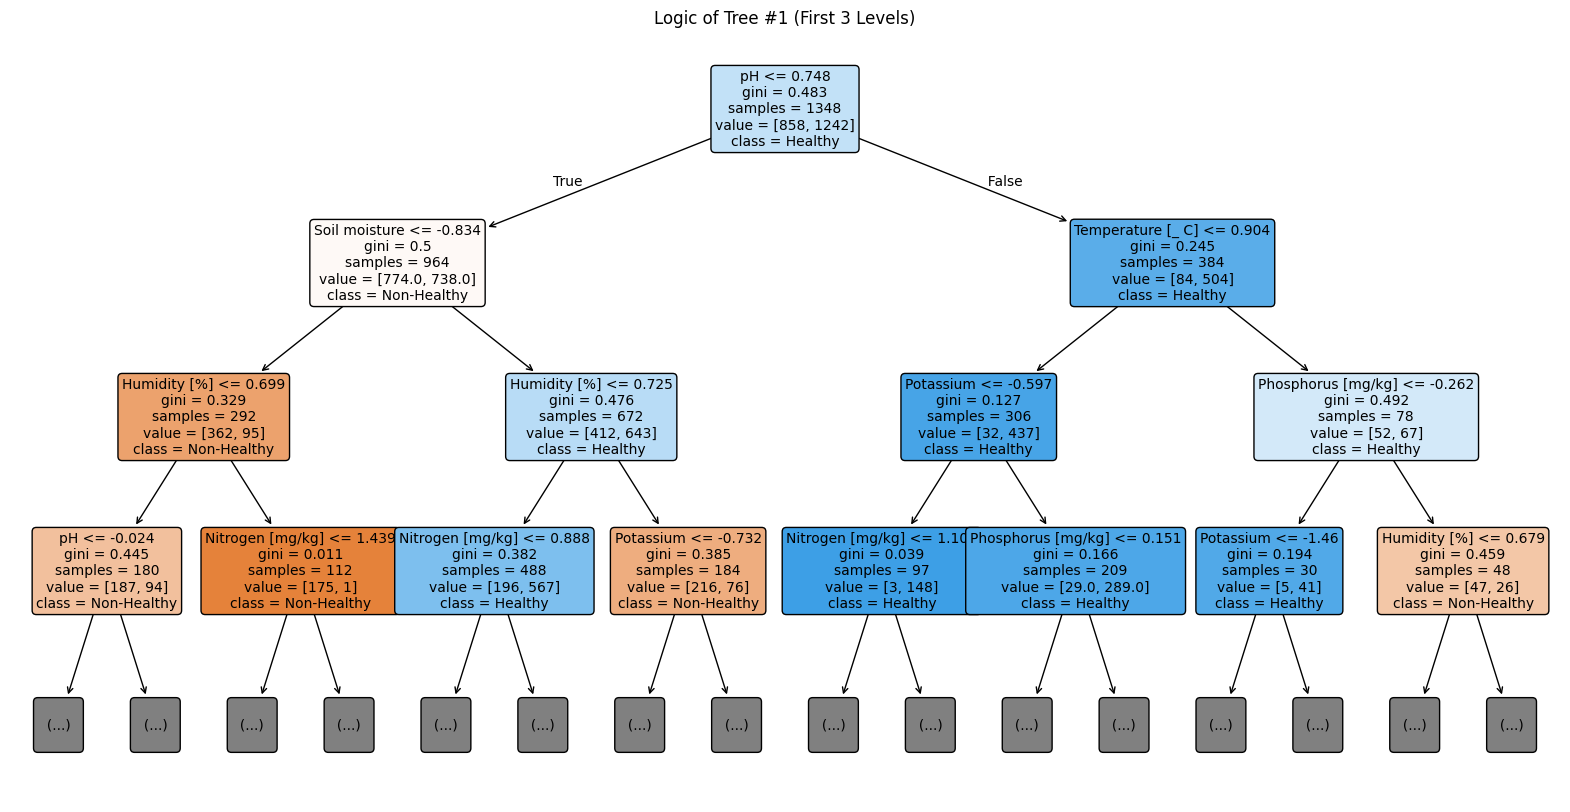

In [ ]:
# =============================================================================
# VISUALIZE A SINGLE TREE FROM THE FOREST
# =============================================================================
from sklearn.tree import plot_tree

print("=" * 60)
print("VISUALIZING TREE LOGIC")
print("=" * 60)

# We pick the first tree from your final model (rf_final)
# Note: We limit depth to 3 so the text is readable
plt.figure(figsize=(20, 10))
plot_tree(rf.estimators_[0],
          feature_names=X.columns,
          class_names=['Non-Healthy', 'Healthy'],
          filled=True,
          rounded=True,
          max_depth=3,
          fontsize=10)
plt.title("Logic of Tree #1 (First 3 Levels)")
plt.show()

In [ ]:
# =============================================================================
# FINAL MODEL
# =============================================================================

best_idx = np.argmax(val_accuracies)
best_n_est = list(n_estimators_range)[best_idx]
print(f"Best n_estimators: {best_n_est} (Val Accuracy: {val_accuracies[best_idx]*100:.2f}%)")

# Train final model
rf_final = RandomForestClassifier(n_estimators=best_n_est, random_state=42, n_jobs=-1)
rf_final.fit(X_train_scaled, y_train)

# Evaluate
y_pred = rf_final.predict(X_test_scaled)

print("\n" + "=" * 60)
print("FINAL RESULTS")
print("=" * 60)
print(f"\nTest Accuracy: {accuracy_score(y_test, y_pred)*100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Non-Healthy', 'Healthy']))

Best n_estimators: 110 (Val Accuracy: 94.89%)

FINAL RESULTS

Test Accuracy: 94.67%

Classification Report:
              precision    recall  f1-score   support

 Non-Healthy       0.95      0.93      0.94       190
     Healthy       0.95      0.96      0.95       260

    accuracy                           0.95       450
   macro avg       0.95      0.94      0.95       450
weighted avg       0.95      0.95      0.95       450



In [ ]:
# =============================================================================
# FEATURE IMPORTANCE
# =============================================================================

print("=" * 60)
print("FEATURE IMPORTANCE")
print("=" * 60)

feature_imp = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_final.feature_importances_
}).sort_values('Importance', ascending=False)

for i, row in feature_imp.iterrows():
    bar = "█" * int(row['Importance'] * 50)
    print(f"{row['Feature']:<25} {row['Importance']:.3f} {bar}")

FEATURE IMPORTANCE
Soil moisture             0.245 ████████████
Humidity [%]              0.204 ██████████
pH                        0.167 ████████
Temperature [_ C]         0.162 ████████
Phosphorus [mg/kg]        0.140 ███████
Potassium                 0.041 ██
Nitrogen [mg/kg]          0.040 █


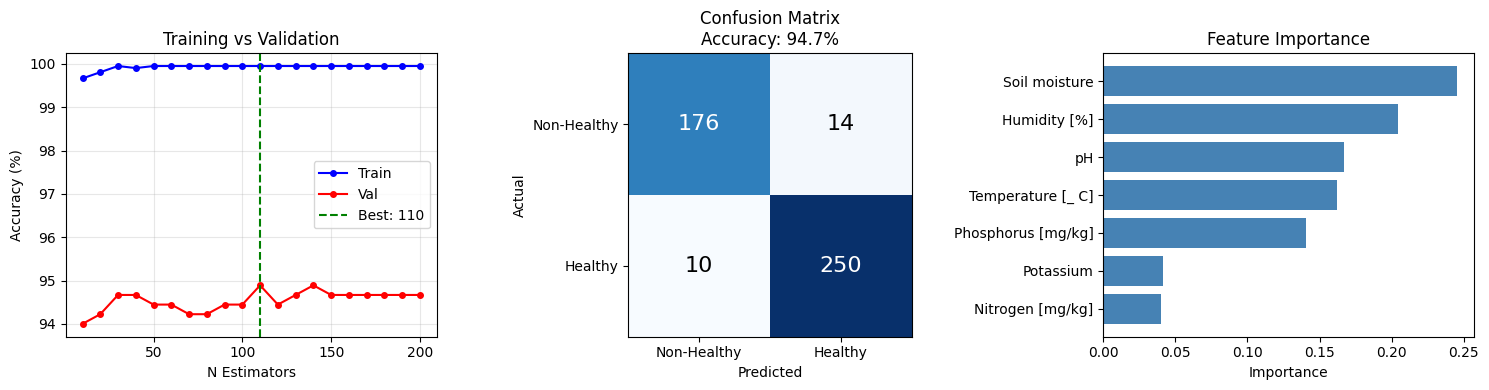


✓ Plot saved: results.png


In [ ]:
# =============================================================================
# PLOT RESULTS
# =============================================================================

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Plot 1: Accuracy vs N_Estimators
axes[0].plot(list(n_estimators_range), [acc*100 for acc in train_accuracies], 'b-o', label='Train', markersize=4)
axes[0].plot(list(n_estimators_range), [acc*100 for acc in val_accuracies], 'r-o', label='Val', markersize=4)
axes[0].axvline(x=best_n_est, color='g', linestyle='--', label=f'Best: {best_n_est}')
axes[0].set_xlabel('N Estimators')
axes[0].set_ylabel('Accuracy (%)')
axes[0].set_title('Training vs Validation')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
axes[1].imshow(cm, cmap='Blues')
axes[1].set_xticks([0, 1])
axes[1].set_yticks([0, 1])
axes[1].set_xticklabels(['Non-Healthy', 'Healthy'])
axes[1].set_yticklabels(['Non-Healthy', 'Healthy'])
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')
axes[1].set_title(f'Confusion Matrix\nAccuracy: {accuracy_score(y_test, y_pred)*100:.1f}%')
for i in range(2):
    for j in range(2):
        color = 'white' if cm[i,j] > cm.max()/2 else 'black'
        axes[1].text(j, i, cm[i,j], ha='center', va='center', fontsize=16, color=color)

# Plot 3: Feature Importance
axes[2].barh(feature_imp['Feature'], feature_imp['Importance'], color='steelblue')
axes[2].set_xlabel('Importance')
axes[2].set_title('Feature Importance')
axes[2].invert_yaxis()

plt.tight_layout()
plt.savefig('results.png', dpi=150)
plt.show()
print("\n✓ Plot saved: results.png")

---
## PREDICT NEW SENSOR DATA
---

In [ ]:
# =============================================================================
# UPLOAD NEW SENSOR DATA
# =============================================================================

import ipywidgets as widgets
from IPython.display import display
import io

print("=" * 60)
print("UPLOAD NEW SENSOR DATA")
print("=" * 60)
print("\nClick button to choose file (.xlsx, .xls, .csv):\n")

file_upload = widgets.FileUpload(accept='.xlsx,.xls,.csv', multiple=False)
display(file_upload)

UPLOAD NEW SENSOR DATA

Click button to choose file (.xlsx, .xls, .csv):



FileUpload(value={}, accept='.xlsx,.xls,.csv', description='Upload')

In [ ]:
# =============================================================================
# LOAD AND PREDICT
# =============================================================================

DEFAULT_TEMPERATURE = 19.16
DEFAULT_HUMIDITY = 64.88

if len(file_upload.value) == 0:
    print("⚠️ Please upload a file first!")
else:
    # Get file
    try:
        uploaded = file_upload.value[0]
        file_name = uploaded.name
        file_content = uploaded.content.tobytes()
    except:
        file_name = list(file_upload.value.keys())[0]
        file_content = file_upload.value[file_name]['content']

    print(f"✓ File: {file_name}")

    # Read file
    if file_name.endswith('.csv'):
        df_new = pd.read_csv(io.BytesIO(file_content))
    elif file_name.endswith('.xlsx'):
        df_new = pd.read_excel(io.BytesIO(file_content), engine='openpyxl')
    else:
        df_new = pd.read_excel(io.BytesIO(file_content), engine='xlrd')

    # Fill NaN
    if 'Temperature' in df_new.columns:
        df_new['Temperature'] = df_new['Temperature'].fillna(DEFAULT_TEMPERATURE)
    if 'Humidity' in df_new.columns:
        df_new['Humidity'] = df_new['Humidity'].fillna(DEFAULT_HUMIDITY)

    # Column mapping
    column_mapping = {
        'Temperature': 'Temperature [_ C]',
        'Humidity': 'Humidity [%]',
        'SoilMoisture': 'Soil moisture',
        'Nitrogen': 'Nitrogen [mg/kg]',
        'Phosphorus': 'Phosphorus [mg/kg]',
        'Potassium': 'Potassium',
        'Ph': 'pH'
    }
    df_new_mapped = df_new.rename(columns=column_mapping)

    # Build features (only 7 features)
    X_new = df_new_mapped[X.columns].copy()

    # Predict
    X_new_scaled = scaler.transform(X_new)
    predictions = predictions = rf_final.predict(X_new_scaled)
    probabilities = rf_final.predict_proba(X_new_scaled)

    df_new['Prediction'] = ['Healthy' if p == 1 else 'Non-Healthy' for p in predictions]
    df_new['Confidence'] = [max(prob) * 100 for prob in probabilities]

    # Results
    print(f"✓ Loaded: {len(df_new)} samples\n")
    print("=" * 60)
    print("RESULTS")
    print("=" * 60)
    print(f"\nHealthy: {(df_new['Prediction']=='Healthy').sum()}")
    print(f"Non-Healthy: {(df_new['Prediction']=='Non-Healthy').sum()}")

    print(f"\n{'#':<3} {'Temp':<6} {'Humid':<6} {'Soil':<6} {'pH':<5} {'N':<4} {'P':<4} {'K':<5} {'Prediction':<12} {'Conf'}")
    print("-" * 65)
    for idx, row in df_new.iterrows():
        print(f"{idx+1:<3} {row.get('Temperature',0):<6.1f} {row.get('Humidity',0):<6.1f} {row.get('SoilMoisture',0):<6.1f} {row.get('Ph',0):<5.2f} {row.get('Nitrogen',0):<4} {row.get('Phosphorus',0):<4} {row.get('Potassium',0):<5} {row['Prediction']:<12} {row['Confidence']:.0f}%")

    # Save
    df_new.to_csv('predictions.csv', index=False)
    print(f"\n✓ Saved to: predictions.csv")

⚠️ Please upload a file first!


In [ ]:
# =============================================================================
# PREDICT FROM RAW DATA
# =============================================================================

import pandas as pd
import numpy as np

# Default values
DEFAULT_TEMPERATURE = 19.16
DEFAULT_HUMIDITY = 64.88

# Feature order (7 features)
FEATURE_COLUMNS = [
    'Temperature [_ C]',
    'Humidity [%]',
    'Soil moisture',
    'Nitrogen [mg/kg]',
    'Phosphorus [mg/kg]',
    'Potassium',
    'pH'
]

def predict_plant_health(
    Temperature=None,
    Humidity=None,
    SoilMoisture=None,
    Nitrogen=None,
    Phosphorus=None,
    Potassium=None,
    Ph=None,
    model=None,
    scaler=None
):
    if model is None or scaler is None:
        raise ValueError("You must provide both the trained RandomForest model and scaler.")

    # Fill missing values
    Temperature = DEFAULT_TEMPERATURE if Temperature is None else Temperature
    Humidity = DEFAULT_HUMIDITY if Humidity is None else Humidity
    SoilMoisture = 0 if SoilMoisture is None else SoilMoisture
    Nitrogen = 0 if Nitrogen is None else Nitrogen
    Phosphorus = 0 if Phosphorus is None else Phosphorus
    Potassium = 0 if Potassium is None else Potassium
    Ph = 7.0 if Ph is None else Ph

    # Create dataframe
    df_new = pd.DataFrame([{
        'Temperature [_ C]': Temperature,
        'Humidity [%]': Humidity,
        'Soil moisture': SoilMoisture,
        'Nitrogen [mg/kg]': Nitrogen,
        'Phosphorus [mg/kg]': Phosphorus,
        'Potassium': Potassium,
        'pH': Ph
    }])

    # Scale features
    X_new_scaled = scaler.transform(df_new[FEATURE_COLUMNS])

    # Predict
    predictions = model.predict(X_new_scaled)
    probabilities = model.predict_proba(X_new_scaled)

    # Add results
    df_new['Prediction'] = ['Healthy' if p == 1 else 'Non-Healthy' for p in predictions]
    df_new['Confidence'] = [max(prob) * 100 for prob in probabilities]

    return df_new

result = predict_plant_health(
    Temperature=22.5,
    Humidity=55.0,
    SoilMoisture=30,
    Nitrogen=12,
    Phosphorus=8,
    Potassium=10,
    Ph=6.8,
    model=rf_final,   # your trained RandomForest model
    scaler=scaler     # your fitted StandardScaler
)

print(result)


   Temperature [_ C]  Humidity [%]  Soil moisture  Nitrogen [mg/kg]  \
0               22.5          55.0             30                12   

   Phosphorus [mg/kg]  Potassium   pH Prediction  Confidence  
0                   8         10  6.8    Healthy   78.181818  


In [ ]:
import pandas as pd
import numpy as np

# Create X_array from X (7 features)
X_array = X.values.astype(np.float32)

# Convert model to ONNX
from skl2onnx import convert_sklearn
from skl2onnx.common.data_types import FloatTensorType

initial_type = [('float_input', FloatTensorType([None, 7]))]  # single array input
onnx_model = convert_sklearn(rf_final, initial_types=initial_type)

with open("tomato_model.onnx", "wb") as f:
    f.write(onnx_model.SerializeToString())

print("✓ Model exported to: tomato_model.onnx")

✓ Model exported to: tomato_model.onnx
